# Bab 4: Regression and Prediction

Notebook ini merangkum Bab 4 buku *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck). Bab ini membahas regresi linear, dari model paling sederhana sampai diagnostik untuk mengecek apakah asumsi-asumsi di baliknya terpenuhi, serta cara menangani hubungan yang tidak linear.

Dataset yang dipakai sama dengan buku: `house_sales.csv`, data penjualan rumah di King County (termasuk Seattle), dari repo data resminya di `https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/`. Kolom utamanya:

- `AdjSalePrice`: harga jual rumah yang sudah disesuaikan inflasi (variabel target/response)
- `SqFtTotLiving`, `SqFtLot`, `Bathrooms`, `Bedrooms`, `BldgGrade`: ukuran dan kualitas bangunan (predictor numerik)
- `PropertyType`, `ZipCode`: variabel kategorikal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

sns.set_style("whitegrid")
pd.set_option("display.precision", 4)

BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"
house = pd.read_csv(BASE + "house_sales.csv", sep="\t")

house = house.loc[house["PropertyType"] == "Single Family"].copy()
house.shape

(20720, 22)

In [2]:
house[["AdjSalePrice", "SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7
7,380785.0,1750,34465,1.50,3,8


## 1. Simple Linear Regression

**Regresi linear sederhana** memodelkan hubungan antara satu variabel response (Y) dan satu variabel predictor (X) sebagai garis lurus:

Y = b0 + b1 X + e

- **b0 (intercept)**: nilai Y yang diprediksi kalau X = 0.
- **b1 (slope/koefisien)**: seberapa besar Y berubah untuk tiap kenaikan 1 satuan pada X.
- **e (residual/error)**: selisih antara nilai Y yang sebenarnya dan yang diprediksi model, karena jarang sekali titik data persis jatuh di garis.

Garis terbaik dicari dengan **least squares**, yaitu meminimalkan jumlah kuadrat semua residual. Contoh di buku: memprediksi `AdjSalePrice` dari `SqFtTotLiving` (luas bangunan).

In [3]:
model_sederhana = smf.ols("AdjSalePrice ~ SqFtTotLiving", data=house).fit()
print(model_sederhana.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                 1.950e+04
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        00:49:32   Log-Likelihood:            -2.8973e+05
No. Observations:               20720   AIC:                         5.795e+05
Df Residuals:                   20718   BIC:                         5.795e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -6.106e+04   4972.846    -12.278

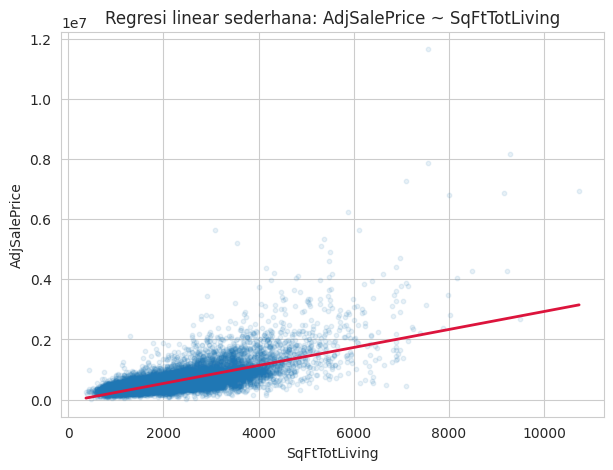

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(house["SqFtTotLiving"], house["AdjSalePrice"], alpha=0.1, s=10)
x_range = np.linspace(house["SqFtTotLiving"].min(), house["SqFtTotLiving"].max(), 100)
y_pred = model_sederhana.params["Intercept"] + model_sederhana.params["SqFtTotLiving"] * x_range
ax.plot(x_range, y_pred, color="crimson", linewidth=2)
ax.set_xlabel("SqFtTotLiving")
ax.set_ylabel("AdjSalePrice")
ax.set_title("Regresi linear sederhana: AdjSalePrice ~ SqFtTotLiving")
plt.show()

In [5]:
intercept = model_sederhana.params["Intercept"]
slope = model_sederhana.params["SqFtTotLiving"]

print(f"Intercept (b0): {intercept:,.0f}")
print(f"Slope (b1)    : {slope:,.2f}")
print(f"\nArtinya, tiap tambahan 1 sqft luas bangunan, harga rumah diprediksi naik sekitar {slope:,.0f} dolar.")

Intercept (b0): -61,058
Slope (b1)    : 298.81

Artinya, tiap tambahan 1 sqft luas bangunan, harga rumah diprediksi naik sekitar 299 dolar.


**Fitted values** adalah nilai Y hasil prediksi model untuk tiap data (titik-titik di garis merah), sementara **residuals** adalah selisih antara nilai asli dan fitted value-nya. Residual inilah yang nanti jadi dasar banyak diagnostik di bagian akhir bab ini.

In [6]:
fitted_values = model_sederhana.fittedvalues
residuals = model_sederhana.resid

print("Contoh fitted values:\n", fitted_values.head())
print("\nContoh residuals:\n", residuals.head())
print(f"\nRMSE (root mean squared error): {np.sqrt((residuals ** 2).mean()):,.0f}")
print(f"R-squared                      : {model_sederhana.rsquared:.3f}")

Contoh fitted values:
 2    1.0637e+06
3    5.5450e+05
4    8.9515e+05
5    4.5290e+05
7    4.6187e+05
dtype: float64

Contoh residuals:
 2     12485.4281
3    207307.0697
4   -453080.6130
5   -155836.2530
7    -81080.6657
dtype: float64

RMSE (root mean squared error): 286,128
R-squared                      : 0.485


## 2. Multiple Linear Regression

Kalau predictornya lebih dari satu, modelnya jadi **multiple linear regression**:

Y = b0 + b1 X1 + b2 X2 + ... + bp Xp + e

Interpretasi tiap koefisien jadi sedikit lebih rumit: bi menunjukkan perubahan Y untuk tiap kenaikan 1 satuan Xi, **dengan asumsi semua predictor lain tetap konstan**. Buku memakai beberapa predictor sekaligus untuk memprediksi harga rumah: luas bangunan, luas tanah, jumlah kamar mandi, jumlah kamar tidur, dan grade bangunan.

In [7]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
formula = "AdjSalePrice ~ " + " + ".join(predictors)

model_multiple = smf.ols(formula, data=house).fit()
print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     4834.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        00:51:03   Log-Likelihood:            -2.8859e+05
No. Observations:               20720   AIC:                         5.772e+05
Df Residuals:                   20714   BIC:                         5.772e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -5.246e+05   1.69e+04    -31.060

In [8]:
print(f"RMSE      : {np.sqrt(model_multiple.mse_resid):,.0f}")
print(f"R-squared : {model_multiple.rsquared:.3f}")
print(f"Adjusted R-squared: {model_multiple.rsquared_adj:.3f}")

RMSE      : 270,842
R-squared : 0.539
Adjusted R-squared: 0.538


Perhatikan bahwa koefisien `Bedrooms` di model ini bernilai **negatif**, padahal secara intuisi rumah dengan lebih banyak kamar tidur biasanya lebih mahal. Ini contoh nyata kenapa interpretasi "dengan predictor lain tetap konstan" penting: pada luas bangunan yang sama, menambah kamar tidur berarti kamar-kamarnya jadi lebih kecil, yang justru dianggap kurang diinginkan pembeli. Fenomena ini akan dibahas lebih lanjut di bagian korelasi antar predictor.

## 3. Prediction Using Regression

Setelah model terbentuk, kita bisa memakainya untuk **memprediksi** nilai Y pada data baru. Tapi penting membedakan dua jenis interval ketidakpastian:

- **Confidence interval**: rentang ketidakpastian untuk nilai rata-rata prediksi (misalnya, rata-rata harga rumah dengan karakteristik tertentu).
- **Prediction interval**: rentang ketidakpastian untuk satu observasi baru yang spesifik. Selalu lebih lebar dari confidence interval, karena menambahkan variasi dari residual individual, bukan cuma ketidakpastian dari estimasi rata-ratanya.

In [9]:
rumah_baru = pd.DataFrame({
    "SqFtTotLiving": [2500],
    "SqFtLot": [6000],
    "Bathrooms": [2],
    "Bedrooms": [3],
    "BldgGrade": [8],
})

prediksi = model_multiple.get_prediction(rumah_baru)
ringkasan_prediksi = prediksi.summary_frame(alpha=0.05)
ringkasan_prediksi

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,720596.0952,3040.2124,714637.0402,726555.1502,189691.4357,1.2515e+06


Kolom `mean_ci_lower`/`mean_ci_upper` adalah confidence interval untuk rata-rata, sementara `obs_ci_lower`/`obs_ci_upper` adalah prediction interval untuk satu rumah baru, jauh lebih lebar karena memperhitungkan variasi harga antar rumah individual, bukan cuma ketidakpastian estimasi rata-ratanya.

## 4. Factor Variables dalam Regresi

Variabel kategorikal (disebut **factor variable** di buku) tidak bisa langsung dimasukkan ke persamaan regresi karena bukan angka. Solusinya adalah **one-hot encoding** / **dummy variable**: tiap kategori (kecuali satu yang jadi referensi) diubah jadi kolom biner 0/1.

`statsmodels` dengan formula API (seperti dipakai di atas) sebenarnya sudah menangani ini otomatis kalau kolomnya bertipe kategorikal/string, tapi penting memahami apa yang terjadi di baliknya.

In [10]:
print("Kategori PropertyType yang tersisa:", house['PropertyType'].unique())

contoh_zip = house[house["ZipCode"].isin([98105, 98108, 98126])][["ZipCode"]].copy()
pd.get_dummies(contoh_zip["ZipCode"], prefix="Zip").head()

Kategori PropertyType yang tersisa: ['Single Family']


,Zip_98105,Zip_98108,Zip_98126
47,False,True,False
71,False,False,True
72,False,False,True
117,False,False,True
118,False,False,True


Satu kategori selalu dijadikan **referensi** (tidak dibuatkan kolom dummy sendiri) supaya tidak terjadi multikolinearitas sempurna antar kolom dummy. Koefisien tiap dummy lainnya diinterpretasikan relatif terhadap kategori referensi ini.

Untuk variabel kategorikal dengan sangat banyak level seperti `ZipCode` (puluhan kode pos), buku menyarankan mengelompokkannya dulu, misalnya berdasarkan median harga rumah di tiap zip code, supaya tidak menghasilkan terlalu banyak kolom dummy sekaligus.

In [11]:
house["ZipGroup"] = pd.qcut(
    house.groupby("ZipCode")["AdjSalePrice"].transform("median"),
    q=5,
    labels=["grup_1_termurah", "grup_2", "grup_3", "grup_4", "grup_5_termahal"],
)

house.groupby("ZipGroup", observed=True)["AdjSalePrice"].median()

,AdjSalePrice
ZipGroup,
grup_1_termurah,322763.0
grup_2,391638.5
grup_3,488480.0
grup_4,585886.0
grup_5_termahal,771620.0


## 5. Menginterpretasikan Persamaan Regresi

Beberapa hal yang perlu diwaspadai saat membaca hasil regresi:

- **Correlated predictors (multikolinearitas)**: kalau dua predictor saling berkorelasi tinggi, koefisien keduanya jadi tidak stabil dan sulit diinterpretasikan sendiri-sendiri, seperti contoh `Bedrooms` di atas.
- **Confounding variables**: variabel penting yang tidak dimasukkan ke model, padahal sebenarnya memengaruhi baik predictor maupun response, bisa membuat hubungan yang terlihat jadi menyesatkan.
- **Interactions**: pengaruh satu predictor terhadap Y bisa berbeda tergantung nilai predictor lain, ini perlu ditambahkan secara eksplisit sebagai suku interaksi di model.

In [12]:
house[predictors].corr().round(3)

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
SqFtTotLiving,1.000,0.183,0.802,0.590,0.803
SqFtLot,0.183,1.000,0.118,0.052,0.150
Bathrooms,0.802,0.118,1.000,0.567,0.684
Bedrooms,0.590,0.052,0.567,1.000,0.409
BldgGrade,0.803,0.150,0.684,0.409,1.000


In [13]:
model_interaksi = smf.ols(
    "AdjSalePrice ~ SqFtTotLiving * ZipGroup + Bathrooms + Bedrooms + BldgGrade",
    data=house,
).fit()
print(model_interaksi.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     2957.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        00:54:04   Log-Likelihood:            -2.8626e+05
No. Observations:               20720   AIC:                         5.725e+05
Df Residuals:                   20707   BIC:                         5.726e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

Istilah `SqFtTotLiving:ZipGroup[...]` pada hasil ini menunjukkan seberapa besar pengaruh luas bangunan terhadap harga berbeda-beda antar kelompok zip code. Kalau koefisien interaksinya signifikan, itu tanda bahwa "harga per sqft" memang tidak seragam di semua wilayah.

## 6. Menguji Asumsi: Regression Diagnostics

Model regresi mengasumsikan beberapa hal soal residualnya. Buku memakai subset data dari satu zip code (98105) untuk mendemonstrasikan diagnostik ini, supaya pola-polanya lebih mudah terlihat dibanding memakai seluruh data King County sekaligus.

In [14]:
house_98105 = house.loc[house["ZipCode"] == 98105].copy()

model_98105 = smf.ols(
    "AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house_98105,
).fit()
print(model_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     212.7
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           1.99e-91
Time:                        00:54:58   Log-Likelihood:                -3734.3
No. Observations:                 276   AIC:                             7481.
Df Residuals:                     270   BIC:                             7502.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -8.345e+05   1.07e+05     -7.774

### Outliers

**Outlier** dalam konteks regresi adalah observasi yang residualnya jauh lebih besar dibanding yang lain, lebih mudah dideteksi dari residualnya dibanding dari nilai mentahnya sendiri.

In [15]:
residuals_98105 = model_98105.resid
std_residuals = residuals_98105 / residuals_98105.std()

outlier_idx = std_residuals.abs().idxmax()
print(f"Index observasi dengan residual paling ekstrem: {outlier_idx}")
print(f"Standardized residual: {std_residuals.loc[outlier_idx]:.2f}")
house_98105.loc[[outlier_idx]]

Index observasi dengan residual paling ekstrem: 14392
Standardized residual: 4.97


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,ZipGroup
14392,2011-08-01,1650000,4219400785,Single Family,2011-08-01,312700,0.7185,2296386.0,1,7200,...,4,9,1936,0,0,467000,1112000,98105,False,grup_4


### Influential Values

Tidak semua outlier sama bahayanya bagi model. **Influential value** adalah observasi yang kalau dihapus, benar-benar mengubah hasil model secara signifikan, ini kombinasi antara seberapa ekstrem nilai predictornya (**leverage**) dan seberapa besar residualnya. Ukuran yang umum dipakai adalah **Cook's distance**.

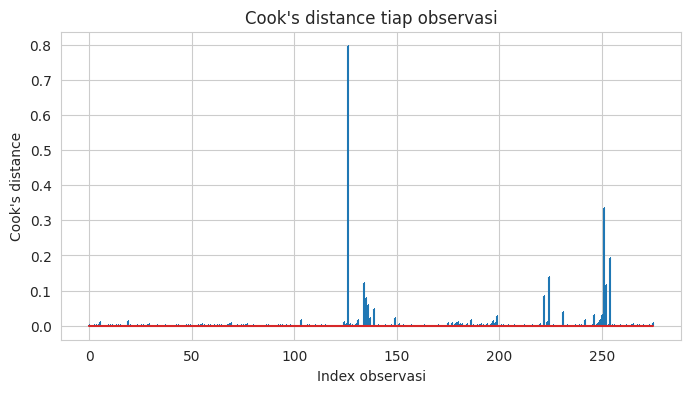

Observasi dengan Cook's distance tertinggi: index 126, nilai 0.7971


In [16]:
influence = model_98105.get_influence()
cooks_d = influence.cooks_distance[0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=",")
ax.set_xlabel("Index observasi")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's distance tiap observasi")
plt.show()

print(f"Observasi dengan Cook's distance tertinggi: index {np.argmax(cooks_d)}, nilai {cooks_d.max():.4f}")

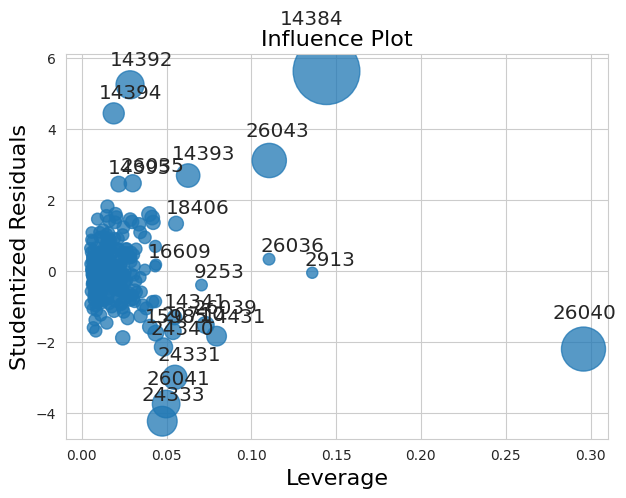

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sm.graphics.influence_plot(model_98105, ax=ax, criterion="cooks")
plt.show()

Plot ini menggabungkan leverage (sumbu x), standardized residual (sumbu y), dan Cook's distance (ukuran bubble) sekaligus. Titik dengan bubble besar di posisi ekstrem adalah kandidat kuat sebagai influential value yang layak diperiksa lebih lanjut, karena bisa jadi itu kesalahan input data, atau justru kasus unik yang perlu ditangani terpisah.

### Heteroskedasticity, Non-Normality, dan Correlated Errors

Regresi linear mengasumsikan residual punya sebaran yang relatif konstan di semua rentang prediksi (**homoskedastisitas**) dan mendekati distribusi normal. Pelanggaran asumsi ini tidak selalu membuat model gagal dipakai, tapi bisa membuat confidence interval dan p-value-nya tidak lagi akurat.

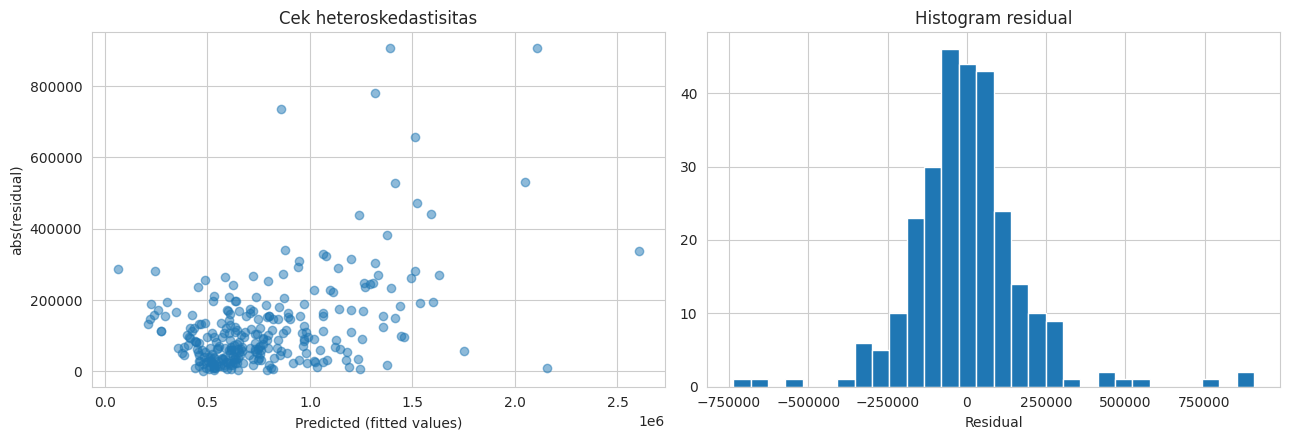

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(model_98105.fittedvalues, residuals_98105.abs(), alpha=0.5)
axes[0].set_xlabel("Predicted (fitted values)")
axes[0].set_ylabel("abs(residual)")
axes[0].set_title("Cek heteroskedastisitas")

axes[1].hist(residuals_98105, bins=30, edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_title("Histogram residual")

plt.tight_layout()
plt.show()

Kalau titik-titik pada plot kiri cenderung makin menyebar lebar di satu sisi (biasanya di prediksi yang lebih tinggi), itu tanda heteroskedastisitas: variabilitas error-nya tidak konstan. Histogram di kanan dipakai untuk mengecek kewajaran asumsi normalitas residual; residual yang jauh dari bentuk lonceng simetris bisa jadi tanda model masih kehilangan sesuatu, misalnya hubungan nonlinear yang belum ditangkap.

Untuk data yang dikumpulkan berurutan dalam waktu atau ruang, ada juga asumsi bahwa error-nya **independen** (tidak saling berkorelasi). Pelanggaran ini biasa dicek dengan **Durbin-Watson statistic**, yang relevan terutama untuk data time series.

### Partial Residual Plots dan Nonlinearitas

**Partial residual plot** menunjukkan hubungan antara satu predictor dan response, setelah pengaruh predictor lain "dikeluarkan" lebih dulu dari persamaan. Plot ini berguna untuk melihat apakah hubungan predictor itu benar-benar linear, atau sebenarnya melengkung dan belum ditangkap dengan baik oleh model linear biasa.

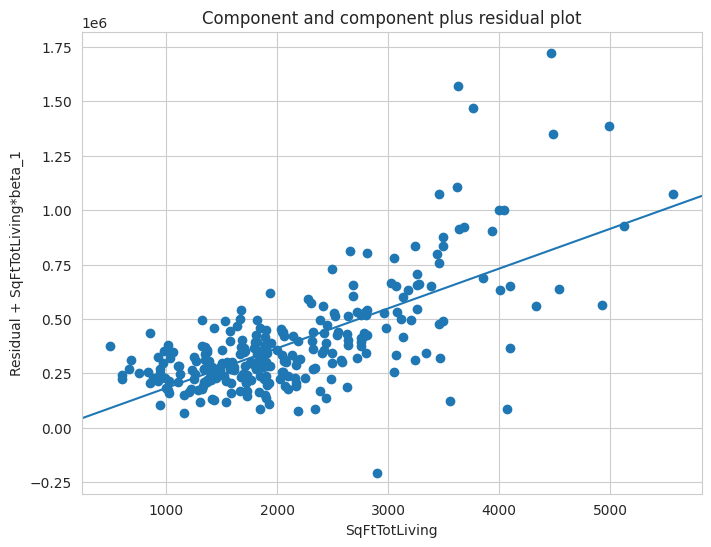

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.plot_ccpr(model_98105, "SqFtTotLiving", ax=ax)
plt.show()

Kalau garis smoothing (biasanya ditampilkan putus-putus) pada plot ini melengkung menjauh dari garis linear modelnya, itu tanda hubungan `SqFtTotLiving` terhadap harga sebenarnya tidak sepenuhnya linear, misalnya menambah luas pada rumah kecil mungkin berdampak beda dibanding menambah luas yang sama pada rumah yang sudah besar. Ini mengarah ke solusi di bagian terakhir bab ini.

## 7. Polynomial dan Spline Regression

Kalau hubungan antara predictor dan response tidak linear, salah satu solusinya adalah menambahkan suku **polynomial** (misalnya kuadrat dari predictor), atau memakai **spline**, yaitu potongan-potongan kurva (biasanya polynomial berderajat rendah) yang disambung mulus di titik-titik tertentu yang disebut **knots**.

Polynomial regression gampang diterapkan tapi punya kelemahan: kalau derajatnya terlalu tinggi, kurvanya jadi "liar" (wiggly) di ujung-ujung rentang data. Spline biasanya memberi hasil yang lebih halus dan stabil.

In [20]:
model_polinomial = smf.ols(
    "AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving ** 2) + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house_98105,
).fit()
print(model_polinomial.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     198.3
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           1.09e-95
Time:                        00:57:52   Log-Likelihood:                -3721.4
No. Observations:                 276   AIC:                             7457.
Df Residuals:                     269   BIC:                             7482.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -6.561e+

In [21]:
model_spline = smf.ols(
    "AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house_98105,
).fit()
print(model_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     123.3
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           1.34e-93
Time:                        00:57:59   Log-Likelihood:                -3715.7
No. Observations:                 276   AIC:                             7453.
Df Residuals:                     265   BIC:                             7493.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


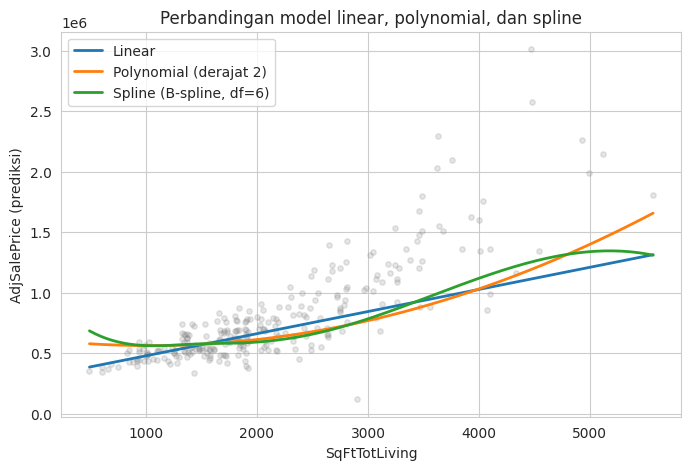

In [22]:
sqft_range = pd.DataFrame({
    "SqFtTotLiving": np.linspace(house_98105["SqFtTotLiving"].min(), house_98105["SqFtTotLiving"].max(), 200),
    "SqFtLot": house_98105["SqFtLot"].median(),
    "Bathrooms": house_98105["Bathrooms"].median(),
    "Bedrooms": house_98105["Bedrooms"].median(),
    "BldgGrade": house_98105["BldgGrade"].median(),
})

pred_linear = model_98105.predict(sqft_range)
pred_poly = model_polinomial.predict(sqft_range)
pred_spline = model_spline.predict(sqft_range)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(house_98105["SqFtTotLiving"], house_98105["AdjSalePrice"], alpha=0.2, s=15, color="gray")
ax.plot(sqft_range["SqFtTotLiving"], pred_linear, label="Linear", linewidth=2)
ax.plot(sqft_range["SqFtTotLiving"], pred_poly, label="Polynomial (derajat 2)", linewidth=2)
ax.plot(sqft_range["SqFtTotLiving"], pred_spline, label="Spline (B-spline, df=6)", linewidth=2)
ax.set_xlabel("SqFtTotLiving")
ax.set_ylabel("AdjSalePrice (prediksi)")
ax.set_title("Perbandingan model linear, polynomial, dan spline")
ax.legend()
plt.show()

Dari perbandingan ini biasanya terlihat garis linear tidak menangkap kelengkungan hubungan di ujung-ujung rentang data, sementara polynomial dan spline lebih fleksibel mengikuti pola sebenarnya. Spline cenderung lebih stabil dibanding polynomial derajat tinggi, karena tiap segmennya hanya perlu menyesuaikan diri secara lokal, bukan memaksa satu kurva tunggal mengikuti seluruh rentang data sekaligus.

Pendekatan yang lebih fleksibel lagi dari spline adalah **Generalized Additive Models (GAM)**, yang memodelkan hubungan nonlinear secara otomatis tanpa perlu menentukan derajat polynomial atau posisi knot secara manual, tapi topik ini tidak dibahas mendalam lagi di buku ini.

## Poin-poin Penting Bab 4

- Regresi linear mencari garis (atau hyperplane untuk banyak predictor) yang meminimalkan jumlah kuadrat residual.
- Pada multiple regression, tiap koefisien diinterpretasikan dengan asumsi predictor lain tetap konstan, dan ini bisa menghasilkan tanda koefisien yang berlawanan dengan intuisi kalau predictornya saling berkorelasi.
- Prediction interval untuk satu observasi baru selalu lebih lebar dari confidence interval untuk rata-rata, karena memperhitungkan variasi individual, bukan cuma ketidakpastian estimasi.
- Variabel kategorikal perlu diubah jadi dummy variable, dengan satu kategori jadi referensi; untuk kategori yang sangat banyak, pengelompokan dulu bisa membantu.
- Diagnostik regresi (outlier, influential value, heteroskedastisitas, partial residual plot) penting untuk mengecek apakah model dan asumsinya masih masuk akal untuk data yang dipakai.
- Kalau hubungan predictor-response tidak linear, polynomial atau spline regression bisa menangkap kelengkungan itu, dengan spline umumnya memberi hasil lebih stabil.

Referensi: Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists*, 2nd Edition, Bab 4 "Regression and Prediction". O'Reilly Media. Dataset: repo data resmi buku di GitHub (gedeck/practical-statistics-for-data-scientists).